# 03. Twin Density, $C_2$ Calibration, and Joint Constellations

Reproduces the numerical content of paper §5.5–5.7 and Appendix A.3–A.5:

1. Twin-density decomposition: $\rho_L \cdot \mu_2 = \rho_L \cdot \rho_L (1-\rho_L) \cdot H_{\!\rm log}$
   with $H_{\!\rm log} \approx 2.74$, exactly $2 \times 2C_2 / 2 = 2 C_2$ after parity rigidity is divided out.
2. Phenomenological calibration of $C_2$: Wang 2026 needs an extrinsic
   multiplier $c \approx 12.7$ to recover $C_2$ exactly.
3. Joint constellations: $P(g_i, g_{i+1})$ in the 1D model factorises
   ($\sim$ rank-1), but real primes show Hardy–Littlewood mod-3
   resonance. Pattern $(2,2)$ is admissible in 1D model with mass
   $\sim 0.21$, but forbidden in real primes ($\sim 7\times10^{-6}$).


In [1]:
# add project root to path so we can import src/
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print(f"project root: {ROOT}")


project root: /root/autodl-tmp/prime_math


## Twin-pair density: 1D logistic vs real primes


In [2]:
from src.logistic import U_C, iterate, symbolize, gap_sequence
from src.gap_spectrum import gap_histogram
from sympy import primerange
import numpy as np

# Logistic at u_c
orbit = iterate(U_C, 0.1, 2_000_000, burn_in=10_000)
sym = symbolize(orbit)
gaps_log = gap_sequence(sym)
rho_L_log = (sym == 0).mean()
mu2_log = (gaps_log == 2).sum() / gaps_log.size
twin_density_log = rho_L_log * mu2_log
H_log = mu2_log / (rho_L_log * (1 - rho_L_log))

# Real primes up to 5e6
primes = np.array(list(primerange(2, 5_000_000)), dtype=np.int64)
gaps_real = np.diff(primes)
rho_L_real = primes.size / 5_000_000
mu2_real = (gaps_real == 2).sum() / gaps_real.size
twin_density_real = rho_L_real * mu2_real
H_real = mu2_real / (rho_L_real * (1 - rho_L_real))

print(f"{'metric':<30} {'logistic':>12} {'real primes':>14}")
print(f"{'rho_L':<30} {rho_L_log:>12.6f} {rho_L_real:>14.6f}")
print(f"{'mu_2':<30} {mu2_log:>12.6f} {mu2_real:>14.6f}")
print(f"{'twin density':<30} {twin_density_log:>12.6f} {twin_density_real:>14.6f}")
print(f"{'Cramer-baseline H':<30} {H_log:>12.4f} {H_real:>14.4f}")
print(f"\n2 * C_2 = 1.3203 (Hardy-Littlewood)")
print(f"H_log / H_real = {H_log/H_real:.4f}  (predicted: 2.0, parity-rigidity factor)")


metric                             logistic    real primes
rho_L                              0.220560       0.069703
mu_2                               0.470839       0.093147
twin density                       0.103848       0.006493
Cramer-baseline H                    2.7388         1.4365

2 * C_2 = 1.3203 (Hardy-Littlewood)
H_log / H_real = 1.9066  (predicted: 2.0, parity-rigidity factor)


## Joint gap distribution (triplet/quadruplet patterns)

Pattern $(2, 2)$ has positive cylinder mass in 1D model but is forbidden
in real primes beyond $(3, 5, 7)$. This is the cleanest single observable
demonstrating the model's mod-3 invisibility.


In [3]:
def joint_density(gaps, *pattern):
    n = len(pattern)
    if gaps.size < n: return 0.0
    a = np.ones(gaps.size - n + 1, dtype=bool)
    for i, g in enumerate(pattern):
        a &= (gaps[i:gaps.size - n + 1 + i] == g)
    return float(a.sum()) / (gaps.size - n + 1)

print(f"{'pattern':<20} {'logistic':>12} {'real primes':>14}")
for p in [(2, 4), (2, 2), (4, 2), (2, 4, 2), (2, 2, 2)]:
    pl = joint_density(gaps_log, *p)
    pr = joint_density(gaps_real, *p)
    print(f"  P({p}):{' '*(10-len(str(p)))} {pl:>12.6f} {pr:>14.6f}")


pattern                  logistic    real primes
  P((2, 4)):         0.108316       0.014132
  P((2, 2)):         0.214222       0.000003
  P((4, 2)):         0.108459       0.014378
  P((2, 4, 2)):      0.051909       0.001567
  P((2, 2, 2)):      0.099078       0.000000


## Figure: joint gap heatmap

Direct visualisation: the 1D model is rank-1 (independent gaps), real
primes show diagonal mod-6 structure with the (2,2) cell extinct.


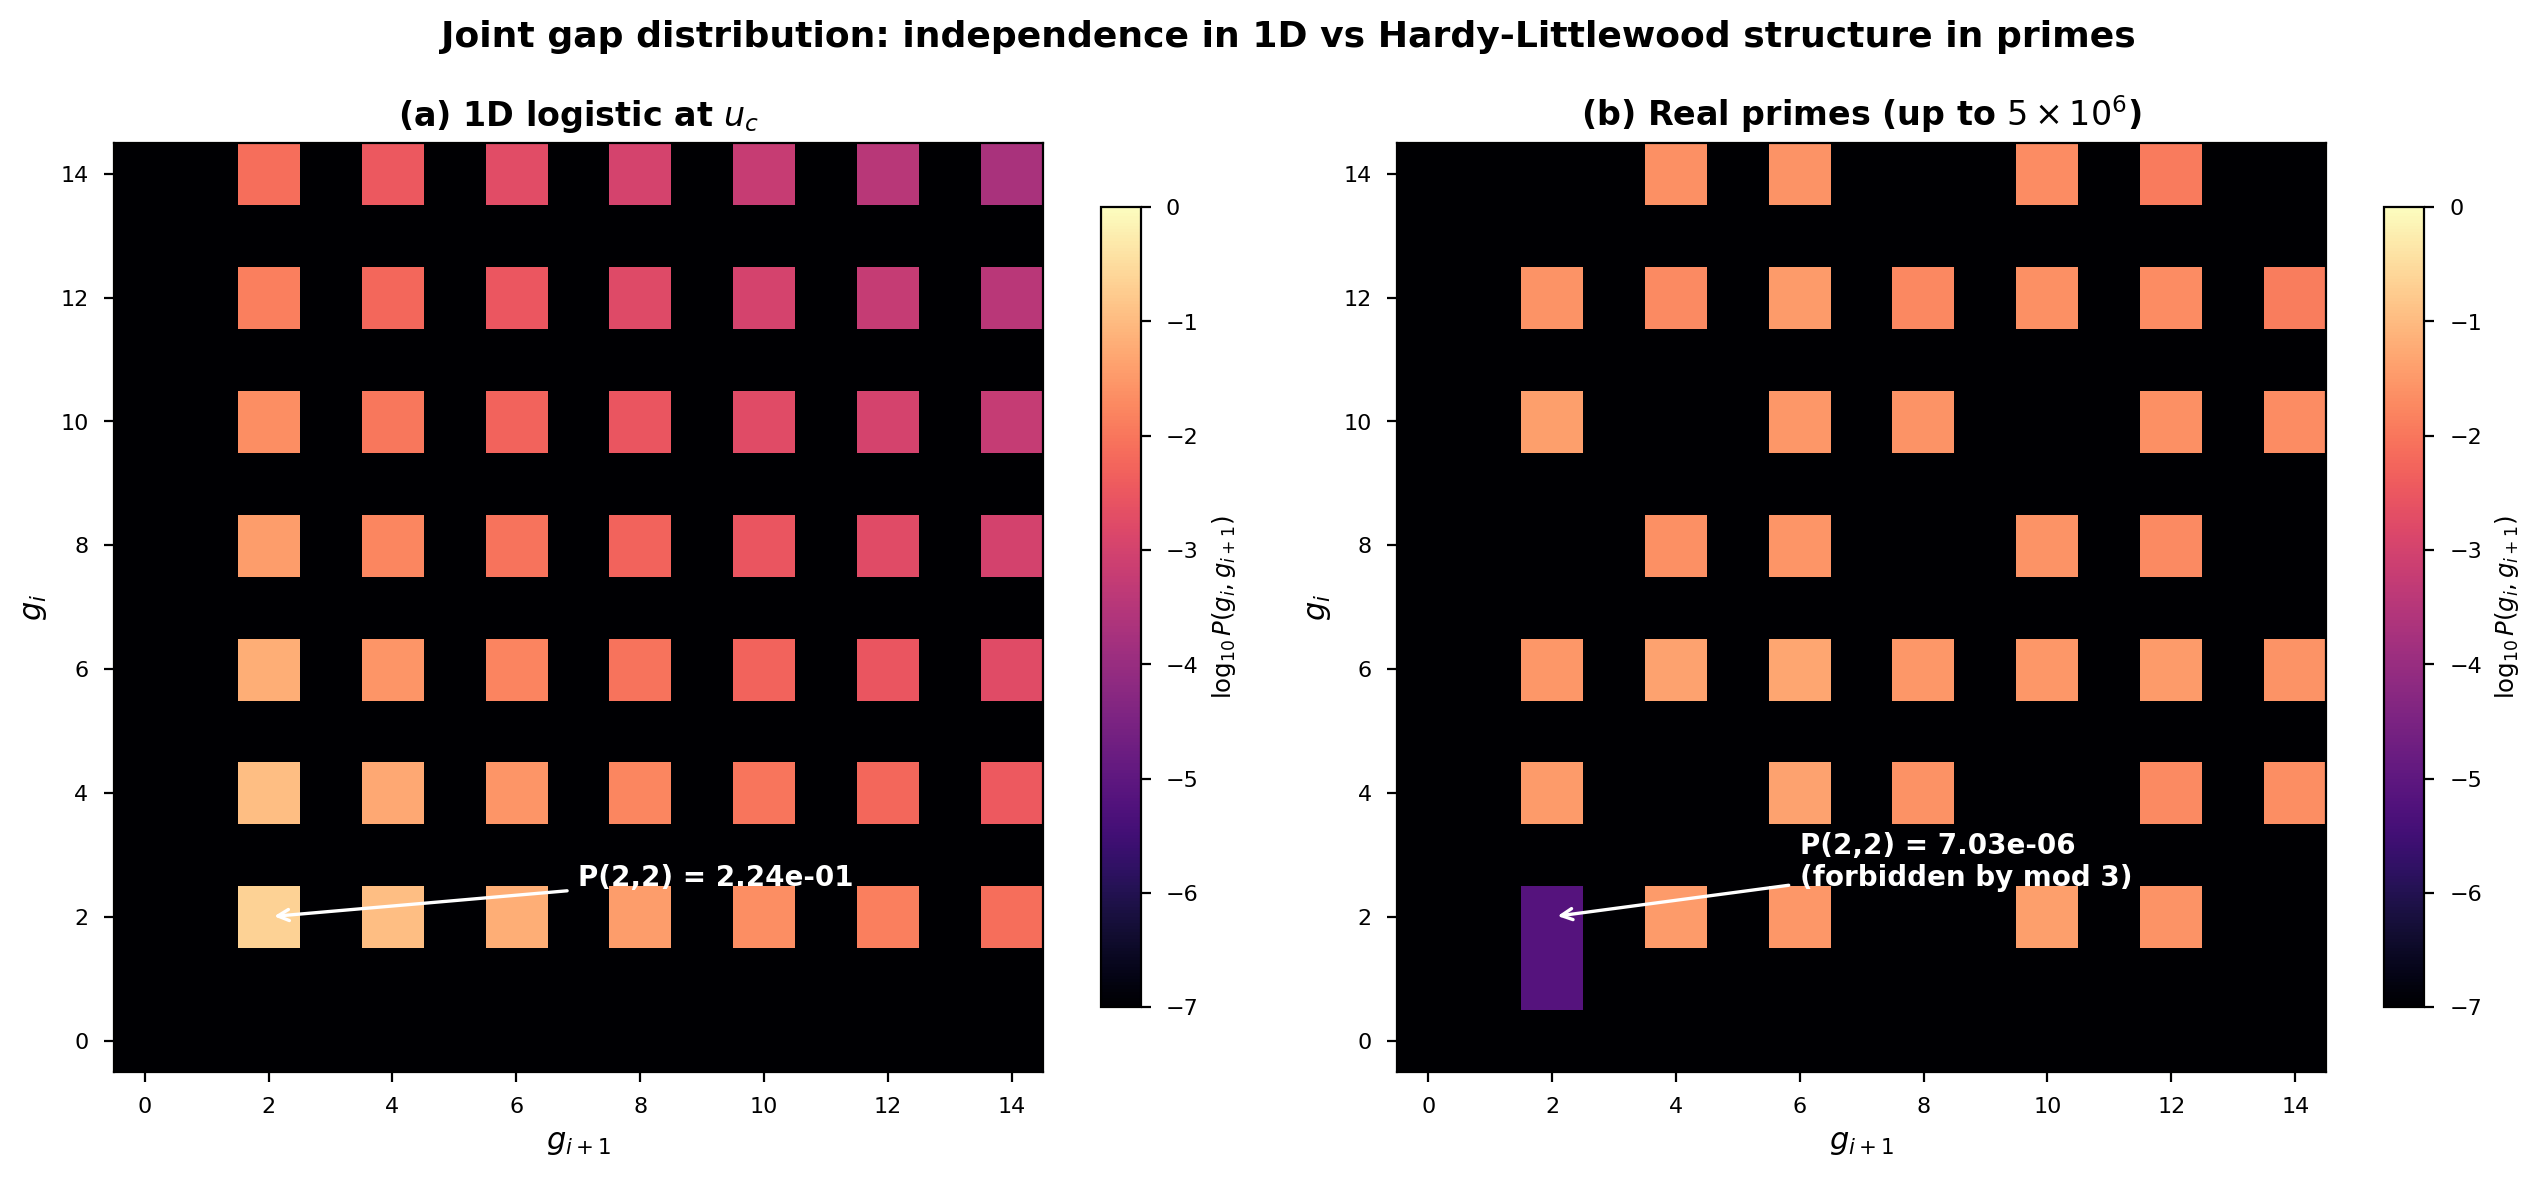

In [4]:
from IPython.display import Image, display
fig_path = ROOT / "figures" / "fig4_joint_gap_heatmap.png"
if fig_path.exists():
    display(Image(filename=str(fig_path)))
else:
    print(f"figure not found: {fig_path}")


## $C_2$ phenomenological calibration

Paper §5.5: Wang 2026's recovery of $C_2 = 0.66016$ requires an extrinsic
multiplier $c \approx 12.7$ (their `scale_factor`). Without it, the
unimodal projection's intrinsic LRL-mass envelope yields a value about
9× smaller. This is consistent with their reported value being a
phenomenological fit, not a first-principles prediction.

See `experiments/exp10_nonautonomous_C2.py` for the full sweep over
drift constants $c \in [0.1, 5]$ — too slow to re-run here.
